In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

In [ ]:
file_path = "AmesHousing.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shashanknecrothapa/ames-housing-dataset",
  file_path,
)

/tmp/ipykernel_7387/348707654.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ames-housing-dataset' dataset.


In [ ]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [ ]:
selected_columns = [
    'Overall Qual',   # Օբյեկտի ընդհանուր որակ
    'Gr Liv Area',    # Բնակելի տարածք
    'Year Built',     # Կառուցման տարեթիվ
    'Garage Cars',    # Ավտոտնակների քանակ
    'Total Bsmt SF',  # Նկուղի ընդհանուր մակերես
    'Bedroom AbvGr',  # Ննջասենյակների քանակ
    'Lot Area',       # Հողի մակերես
    'Neighborhood',   # Թաղամաս
    'SalePrice'       # Տան գինը (Target)
]

df = df[selected_columns]

display(df.head(15))

,Overall Qual,Gr Liv Area,Year Built,Garage Cars,Total Bsmt SF,Bedroom AbvGr,Lot Area,Neighborhood,SalePrice
0,6,1656,1960,2.0,1080.0,3,31770,NAmes,215000
1,5,896,1961,1.0,882.0,2,11622,NAmes,105000
2,6,1329,1958,1.0,1329.0,3,14267,NAmes,172000
3,7,2110,1968,2.0,2110.0,3,11160,NAmes,244000
4,5,1629,1997,2.0,928.0,3,13830,Gilbert,189900
5,6,1604,1998,2.0,926.0,3,9978,Gilbert,195500
6,8,1338,2001,2.0,1338.0,2,4920,StoneBr,213500
7,8,1280,1992,2.0,1280.0,2,5005,StoneBr,191500
8,8,1616,1995,2.0,1595.0,2,5389,StoneBr,236500
9,7,1804,1999,2.0,994.0,3,7500,Gilbert,189000


In [ ]:
print(df.isna().sum(), df.shape)
#Qani or Nan arjeqneri qanaky qich e hamematac
#yndhanur dataseti hangist karox enq uxxaki jnjel dranq

Overall Qual     0
Gr Liv Area      0
Year Built       0
Garage Cars      1
Total Bsmt SF    1
Bedroom AbvGr    0
Lot Area         0
Neighborhood     0
SalePrice        0
dtype: int64 (2930, 9)


In [ ]:
df = df.dropna()
df.shape

(2928, 9)

In [ ]:
print("Overall Qual: ", (df["Overall Qual"].unique()))
print("Garage Cars: ", df["Garage Cars"].unique())
print("Bedroom AbvGr: ", df["Bedroom AbvGr"].unique())
print("Neighborhood: ", df["Neighborhood"].unique())


Overall Qual:  [ 6  5  7  8  9  4  3  2 10  1]
Garage Cars:  [2. 1. 3. 0. 4. 5.]
Bedroom AbvGr:  [3 2 1 4 6 5 0 8]
Neighborhood:  ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df[selected_columns[:-1]], df[selected_columns[-1]], test_size=0.2, random_state=42
)

In [ ]:
display(X_train)

,Overall Qual,Gr Liv Area,Year Built,Garage Cars,Total Bsmt SF,Bedroom AbvGr,Lot Area,Neighborhood
2261,8,1484,2006,2.0,1476.0,2,9037,Timber
1678,5,1302,1970,2.0,630.0,3,2016,BrDale
2777,7,1779,1999,2.0,951.0,3,13426,CollgCr
2505,8,1247,2005,2.0,1247.0,1,3316,Somerst
1088,6,1456,2005,2.0,728.0,3,8029,Gilbert
...,...,...,...,...,...,...,...,...
1639,9,1612,2006,2.0,1612.0,2,8035,StoneBr
1095,7,1414,2002,2.0,707.0,3,7750,Gilbert
1130,6,1728,2003,2.0,864.0,3,8791,Somerst
1294,5,1740,1920,1.0,936.0,2,7308,OldTown


In [ ]:
display(y_train)

,SalePrice
2261,265900
1678,106000
2777,217000
2505,197000
1088,176000
...,...
1639,319900
1095,176000
1130,207500
1294,122250


In [ ]:
X_train.shape
for col in selected_columns[:-2]:
  X_train[col] = (X_train[col] - X_train[col].sum()/len(X_train))/X_train[col].std()
  X_test[col] = (X_test[col] - X_test[col].sum()/len(X_test))/X_test[col].std()

display(X_train)
display(X_test)

,Overall Qual,Gr Liv Area,Year Built,Garage Cars,Total Bsmt SF,Bedroom AbvGr,Lot Area,Neighborhood
2261,1.361748,-0.025003,1.147916,0.314638,0.996873,-1.017471,-0.140861,Timber
1678,-0.784425,-0.388816,-0.041709,0.314638,-0.966981,0.190292,-1.038664,BrDale
2777,0.646357,0.564695,0.916600,0.314638,-0.221831,0.190292,0.420377,CollgCr
2505,1.361748,-0.498760,1.114871,0.314638,0.465286,-2.225235,-0.872428,Somerst
1088,-0.069034,-0.080974,1.114871,0.314638,-0.739490,0.190292,-0.269758,Gilbert
...,...,...,...,...,...,...,...,...
1639,2.077139,0.230866,1.147916,0.314638,1.312576,-1.017471,-0.268991,StoneBr
1095,0.646357,-0.164931,1.015736,0.314638,-0.788238,0.190292,-0.305435,Gilbert
1130,-0.069034,0.462748,1.048781,0.314638,-0.423788,0.190292,-0.172318,Somerst
1294,-0.784425,0.486735,-1.693965,-1.017880,-0.256651,-1.017471,-0.361955,OldTown


,Overall Qual,Gr Liv Area,Year Built,Garage Cars,Total Bsmt SF,Bedroom AbvGr,Lot Area,Neighborhood
2392,1.303045,1.406327,1.098547,0.275096,0.286315,0.117712,0.328640,NridgHt
196,-0.747764,-0.113781,-0.989716,-0.974566,-0.496093,0.117712,-0.471491,BrkSide
2309,0.619442,0.642473,-0.094746,0.275096,1.629380,0.117712,0.188460,NAmes
1732,-0.064161,0.442958,1.131694,1.524759,-0.782698,0.117712,-0.057223,Gilbert
1100,1.303045,1.301819,0.932812,1.524759,0.152427,1.327874,0.499929,NoRidge
...,...,...,...,...,...,...,...,...
2445,2.670251,4.017112,0.767076,1.524759,1.794648,1.327874,3.143667,NoRidge
381,0.619442,-0.271492,0.137283,0.275096,0.037367,0.117712,0.025286,NWAmes
1781,1.303045,0.233944,1.131694,1.524759,1.152404,0.117712,0.406599,Somerst
962,-0.064161,-0.191687,0.535047,0.275096,0.669151,0.117712,0.155260,Timber


In [ ]:
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_train = encoder.fit_transform(X_train[['Neighborhood']])
encoded_test = encoder.transform(X_test[['Neighborhood']])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(['Neighborhood']), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(['Neighborhood']), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=['Neighborhood']), encoded_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=['Neighborhood']), encoded_test_df], axis=1)

In [ ]:
display(X_train)

,Overall Qual,Gr Liv Area,Year Built,Garage Cars,Total Bsmt SF,Bedroom AbvGr,Lot Area,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
2261,1.361748,-0.025003,1.147916,0.314638,0.996873,-1.017471,-0.140861,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1678,-0.784425,-0.388816,-0.041709,0.314638,-0.966981,0.190292,-1.038664,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2777,0.646357,0.564695,0.916600,0.314638,-0.221831,0.190292,0.420377,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2505,1.361748,-0.498760,1.114871,0.314638,0.465286,-2.225235,-0.872428,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1088,-0.069034,-0.080974,1.114871,0.314638,-0.739490,0.190292,-0.269758,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639,2.077139,0.230866,1.147916,0.314638,1.312576,-1.017471,-0.268991,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1095,0.646357,-0.164931,1.015736,0.314638,-0.788238,0.190292,-0.305435,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1130,-0.069034,0.462748,1.048781,0.314638,-0.423788,0.190292,-0.172318,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1294,-0.784425,0.486735,-1.693965,-1.017880,-0.256651,-1.017471,-0.361955,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Algorithm 1: Ridge Regression (Via Gradient Descent)


In [ ]:
w = np.zeros(34, dtype=np.float64)
b = 0.0
lr = 0.001
alpha = 10.0
N = len(X_train)

for i in range(8000):
  y_dot = X_train@w + b
  e = y_dot - y_train
  db = e.sum()/N
  dw = (1 / N) * (X_train.T @ e) + (alpha / N) * w
  b = b - lr*db
  w = w - lr*dw
  if i%1000==0:
    print("MAE: ",f"{np.sum(np.abs(y_dot-y_train))/N:.2f}", end = "  ")
    print("RMSE: ", f"{np.sqrt(np.sum(((y_dot-y_train)**2)/N)):.2f}", end = "  ")

    y_mean = np.mean(y_train)
    ss_res = np.sum((y_train - y_dot) ** 2)
    ss_tot = np.sum((y_train - y_mean) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    print("R2 Score: ", f"{r2_score:.2f}")


MAE:  180141.94  RMSE:  195878.16  R2 Score:  -5.48
MAE:  63393.81  RMSE:  71959.98  R2 Score:  0.12
MAE:  28935.07  RMSE:  41368.12  R2 Score:  0.71
MAE:  23401.52  RMSE:  35604.79  R2 Score:  0.79
MAE:  22655.67  RMSE:  34549.13  R2 Score:  0.80
MAE:  22463.03  RMSE:  34207.24  R2 Score:  0.80
MAE:  22321.37  RMSE:  34003.69  R2 Score:  0.80
MAE:  22190.30  RMSE:  33846.94  R2 Score:  0.81


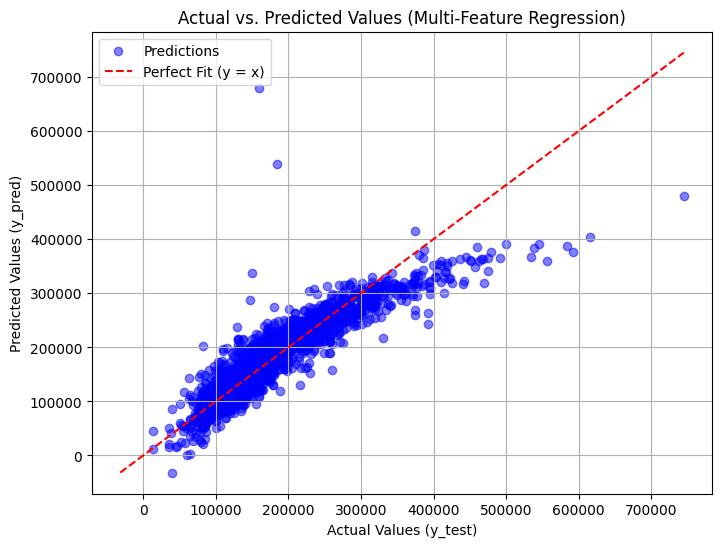

In [ ]:
import matplotlib.pyplot as plt


y_pred = X_train @ w + b

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred, color='blue', alpha=0.5, label='Predictions')

min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit (y = x)')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values (Multi-Feature Regression)')
plt.legend()
plt.grid(True)
plt.show()

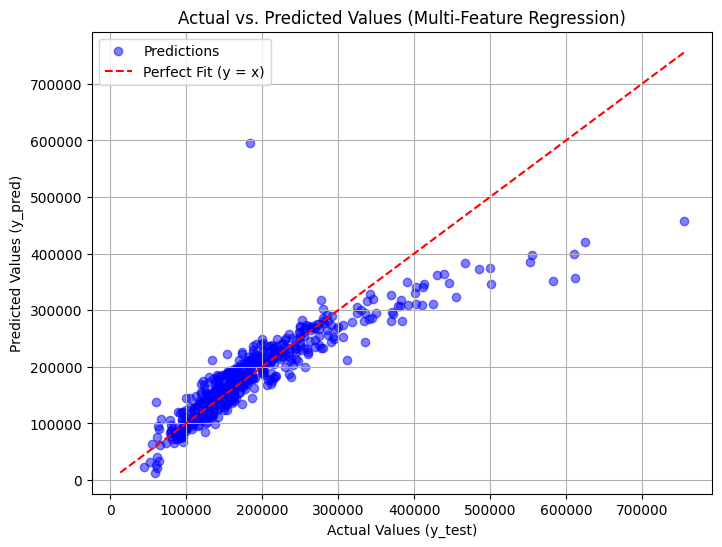

In [ ]:
import matplotlib.pyplot as plt


y_pred = X_test @ w + b

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit (y = x)')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values (Multi-Feature Regression)')
plt.legend()
plt.grid(True)
plt.show()

# Algorithm 2: Lasso Regression (Via Gradient Descent)

In [ ]:
# Still needs to be implemented



# w1 = np.zeros(34, dtype=np.float64)
# b1 = y_train.mean()
# lr1 = 0.001
# alpha = 10.0
# N = len(X_train)

# for i in range(8000):
#   y_dot = X_train@w + b
#   e = y_dot - y_train
#   db = e.sum()/N
#   dw = (1 / N) * (X_train.T @ e) + (alpha / N) * w
#   b = b - lr*db
#   w = w - lr*dw
#   if i%1000==0:
#     print("MAE: ",f"{np.sum(np.abs(y_dot-y_train))/N:.2f}", end = "  ")
#     print("RMSE: ", f"{np.sqrt(np.sum(((y_dot-y_train)**2)/N)):.2f}", end = "  ")

#     y_mean = np.mean(y_train)
#     ss_res = np.sum((y_train - y_dot) ** 2)
#     ss_tot = np.sum((y_train - y_mean) ** 2)
#     r2_score = 1 - (ss_res / ss_tot)
#     print("R2 Score: ", f"{r2_score:.2f}")